--- INFORMACIÓN DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                70000 non-null  int32         
 1   NombreProducto    70000 non-null  object        
 2   Proveedor         70000 non-null  object        
 3   Precio            70000 non-null  float64       
 4   Flete             70000 non-null  float64       
 5   Codigo            70000 non-null  object        
 6   FechaDeCaducidad  70000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(1), object(3)
memory usage: 3.5+ MB

--- FORMA DEL DATAFRAME (SHAPE) ---
(70000, 7)

--- DESCRIPCIÓN ESTADÍSTICA GENERAL ---
                 ID        Precio        Flete               FechaDeCaducidad
count  70000.000000  70000.000000  70000.00000                          70000
mean   35000.500000   1024.712154    155.08541

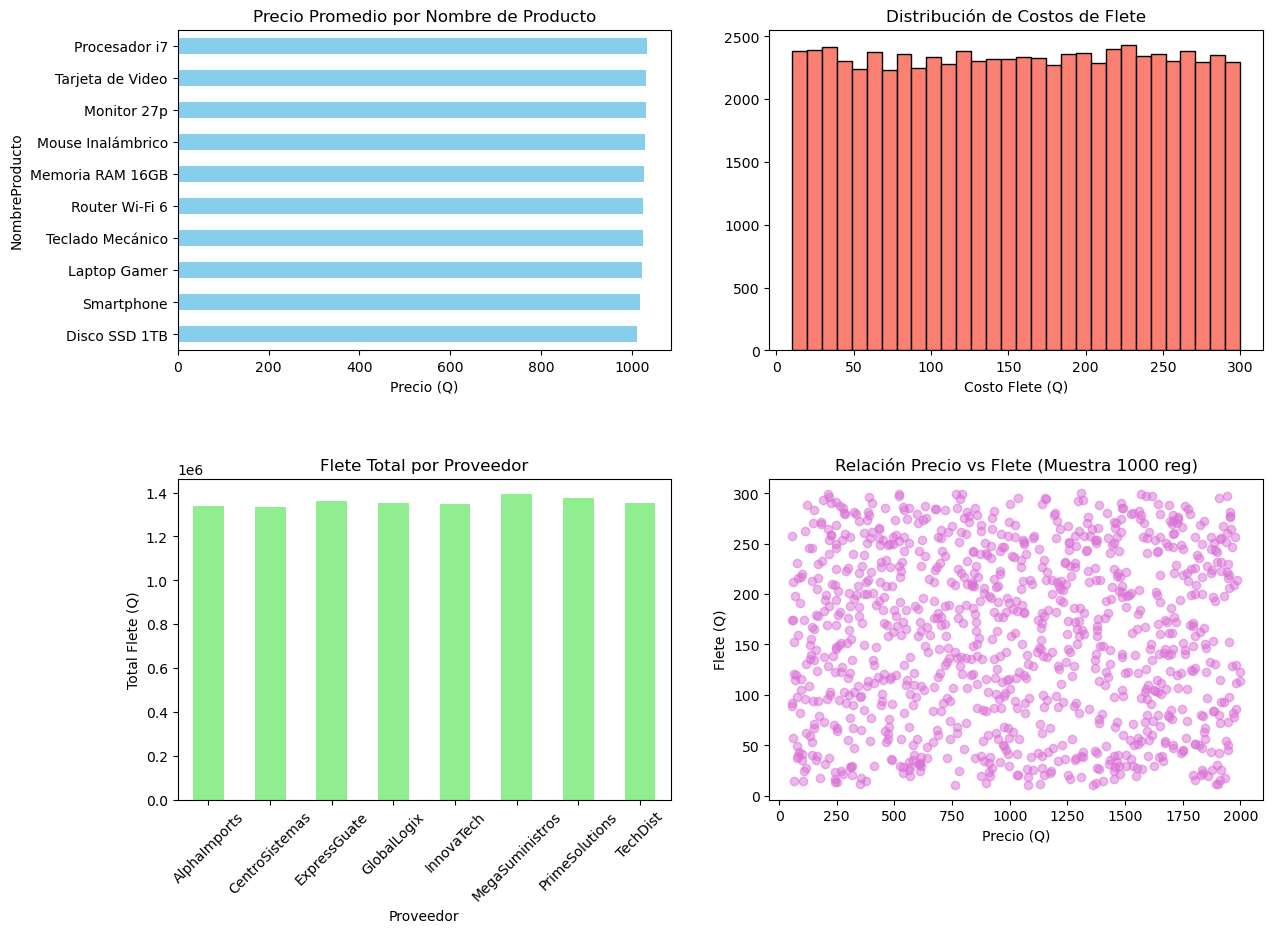

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de parámetros y arreglos de datos (mínimo 8 opciones)
n_registros = 70000

nombres_productos = [
    "Smartphone", "Laptop Gamer", "Monitor 27p", "Teclado Mecánico", 
    "Mouse Inalámbrico", "Disco SSD 1TB", "Memoria RAM 16GB", "Procesador i7",
    "Tarjeta de Video", "Router Wi-Fi 6"
]

proveedores = [
    "TechDist", "GlobalLogix", "InnovaTech", "CentroSistemas", 
    "MegaSuministros", "AlphaImports", "PrimeSolutions", "ExpressGuate"
]

codigos = ["COD-A1", "COD-B2", "COD-C3", "COD-D4", "COD-E5", "COD-F6", "COD-G7", "COD-H8"]

# 2. Generación de datos aleatorios con NumPy
np.random.seed(42) # Semilla para reproducibilidad

data = {
    'ID': np.arange(1, n_registros + 1),
    'NombreProducto': np.random.choice(nombres_productos, n_registros),
    'Proveedor': np.random.choice(proveedores, n_registros),
    'Precio': np.round(np.random.uniform(50, 2000, n_registros), 2),
    'Flete': np.round(np.random.uniform(10, 300, n_registros), 2),
    'Codigo': np.random.choice(codigos, n_registros),
    'FechaDeCaducidad': pd.to_datetime(np.random.choice(pd.date_range('2024-01-01', '2027-12-31'), n_registros))
}

# 3. Crear el DataFrame
df = pd.DataFrame(data)

# 4. Mostrar descripciones del DataFrame
print("--- INFORMACIÓN DEL DATAFRAME ---")
df.info()
print(f"\n--- FORMA DEL DATAFRAME (SHAPE) ---\n{df.shape}")
print("\n--- DESCRIPCIÓN ESTADÍSTICA GENERAL ---")
print(df.describe())

# 5. Análisis estadísticos específicos para Precio y Flete
print("\n--- ANÁLISIS ESTADÍSTICO ESPECÍFICO ---")
analisis = df[['Precio', 'Flete']].agg(['mean', 'median', 'std', 'min', 'max'])
print(analisis)

# 6. Generación de Gráficas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

# Gráfica 1: Precio promedio por Producto (Barras)
df.groupby('NombreProducto')['Precio'].mean().sort_values().plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Precio Promedio por Nombre de Producto')
axes[0,0].set_xlabel('Precio (Q)')

# Gráfica 2: Distribución de Fletes (Histograma)
axes[0,1].hist(df['Flete'], bins=30, color='salmon', edgecolor='black')
axes[0,1].set_title('Distribución de Costos de Flete')
axes[0,1].set_xlabel('Costo Flete (Q)')

# Gráfica 3: Flete total acumulado por Proveedor (Barras)
df.groupby('Proveedor')['Flete'].sum().plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Flete Total por Proveedor')
axes[1,0].set_ylabel('Total Flete (Q)')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfica 4: Relación Precio vs Flete (Muestra de 1000 registros para claridad)
axes[1,1].scatter(df['Precio'].head(1000), df['Flete'].head(1000), alpha=0.5, color='orchid')
axes[1,1].set_title('Relación Precio vs Flete (Muestra 1000 reg)')
axes[1,1].set_xlabel('Precio (Q)')
axes[1,1].set_ylabel('Flete (Q)')

plt.show()